1. Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("../src")

from features.build_features import define_severity, print_class_distribution

2. Load Raw Data

In [4]:
df_raw = pd.read_csv("../data/raw/outbreaks.csv")
print(df_raw.shape)
df_raw.head(3)

(19119, 12)


,Year,Month,State,Location,Food,Ingredient,Species,Serotype/Genotype,Status,Illnesses,Hospitalizations,Fatalities
0,1998,January,California,Restaurant,NaN,NaN,NaN,NaN,NaN,20,0.0,0.0
1,1998,January,California,NaN,Custard,NaN,NaN,NaN,NaN,112,0.0,0.0
2,1998,January,California,Restaurant,NaN,NaN,NaN,NaN,NaN,35,0.0,0.0


3. Define Severity Target

In [5]:
df, low_thresh, high_thresh = define_severity(df_raw, low_pct=0.50, high_pct=0.85)
print_class_distribution(df)

Illnesses thresholds:
  Low  (≤ 50th pct) : <= 8.0
  High (> 85th pct) : >  30.0
  Moderate: everything in between

Class Distribution:
          Count  Percent
Severity                
Low       10163     53.2
Moderate   6152     32.2
High       2804     14.7


,Count,Percent
Severity,,
Low,10163,53.2
Moderate,6152,32.2
High,2804,14.7


4. Visualize Class Distribution

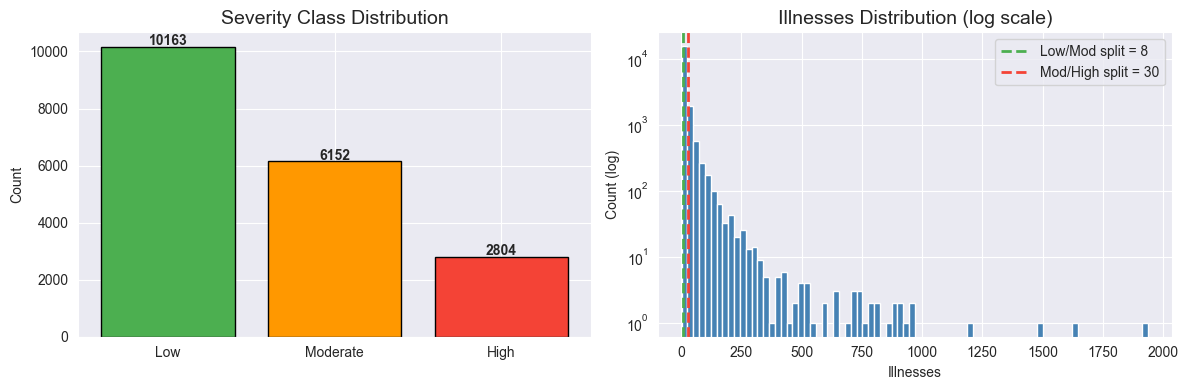

Plot saved.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

order = ["Low", "Moderate", "High"]
counts = df["Severity"].value_counts()[order]
colors = ["#4CAF50", "#FF9800", "#F44336"]
axes[0].bar(order, counts.values, color=colors, edgecolor="black")
axes[0].set_title("Severity Class Distribution", fontsize=14)
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha="center", fontweight="bold")

axes[1].hist(df["Illnesses"], bins=80, color="steelblue", edgecolor="white", log=True)
axes[1].axvline(low_thresh,  color="#4CAF50", linestyle="--", linewidth=2, label=f"Low/Mod split = {low_thresh:.0f}")
axes[1].axvline(high_thresh, color="#F44336", linestyle="--", linewidth=2, label=f"Mod/High split = {high_thresh:.0f}")
axes[1].set_title("Illnesses Distribution (log scale)", fontsize=14)
axes[1].set_xlabel("Illnesses")
axes[1].set_ylabel("Count (log)")
axes[1].legend()

plt.tight_layout()
plt.savefig("../reports/figures/02_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

5. Severity Statistics per Class

In [7]:
df.groupby("Severity")["Illnesses"].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
Severity,,,,,,,,
High,2804.0,82.2,108.5,31.0,39.0,50.0,82.0,1939.0
Low,10163.0,4.0,1.9,2.0,2.0,4.0,5.0,8.0
Moderate,6152.0,16.6,6.0,9.0,11.0,15.0,21.0,30.0


Save Processed File

In [8]:
df.to_csv("../data/processed/outbreaks_with_target.csv", index=False)
print("Saved → data/processed/outbreaks_with_target.csv")
print(f"Shape: {df.shape}")

Saved → data/processed/outbreaks_with_target.csv
Shape: (19119, 14)
